**Técnicas de Aprendizaje Automático**

_Máster Universitario en Inteligencia Artificial_

# Actividad: Clasificación con máquinas de vectores de soporte y árboles de decisión

## Objetivos

Mediante esta actividad se pretende que ponga en práctica la creación de modelos basados en máquinas de vectores de soporte y árboles de decisión. El objetivo es comprender de forma práctica con un problema determinado las diferencias que existen a la hora de entrenar los diferentes modelos.

- Comprender el tratamiento de datos que hay que realizar para los modelos de clasificación.
- Entender y aplicar el algoritmo **Árboles de decisión** a un problema de clasificación.
- Entender y aplicar el algoritmo **Support Vector Machine** a un problema de clasificación.
- Evaluar y analizar los resultados de los clasificadores.
- Investigar la aplicación de los modelos de clasificación a problemas reales.


## Descripción de la actividad

Debes completar los espacios indicados en el notebook con el código solicitado y la respuesta, en función de lo que se solicite. Ten en cuenta que las celdas vacías indican cuántas líneas debe ocupar la respuesta, por lo general no más de una línea.

El conjunto de datos con el que vamos a trabajar se encuentra en el siguiente enlace: https://archive.ics.uci.edu/dataset/31/covertype

Este dataset ha sido generado para predecir el tipo de cubierta forestal únicamente a partir de variables cartográficas (sin datos de sensores remotos). El tipo de cubierta forestal real para una observación determinada (celda de 30 x 30 metros) se determinó a partir de los datos del Sistema de información de recursos (RIS) de la Región 2 del Servicio Forestal de EE. UU. (USFS). Las variables independientes se derivaron de datos obtenidos originalmente del Servicio Geológico de EE. UU. (USGS) y de datos del USFS. Los datos están en forma original (no escalados) y contienen columnas binarias (0 o 1) de datos para variables cualitativas independientes (áreas silvestres y tipos de suelo).
Para ampliar información sobre el dataset y su origen, recomendamos leer la descripción completa del dataset en el enlace del repositorio. l.

El objetivo de la clasificación será detectar el tipo de cubierta forestal.

### Tareas que se deben realizar

- Análisis descriptivo de los datos:
   - Debe completarse el código solicitado y responder a las preguntas. Todo ello en el notebook dado como base.
- Clasificación:
  - Debe completarse el código solicitado y responder a las preguntas. Todo ello en el notebook dado como base.
- Investigación:
  - Buscar un artículo científico (https://scholar.google.es/) con un caso de uso de clasificación empleando una de las dos técnicas (o ambas) vistas en la actividad. Los artículos deben estar en revistas científicas, y deben ser posteriores a 2015. No debe utilizar técnicas de Deep Learning.
  - Para el artículo indicar:
    - Objetivo: cuál es el objetivo de la investigación, es decir a qué problema real está aplicando la **clasificación**.
    - Cómo utilizan las técnicas de **clasificación**, si realizan alguna adaptación de los algoritmos, esta deberá indicarse.
    - Principales resultados de la aplicación y de la investigación.


### Análisis descriptivo de los datos

In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

In [2]:
# se carga el dataset
#df = pd.read_csv('covtype.data', header=None) #adaptar a nuestra ruta
columnas = [
    'Elevation', 'Aspect', 'Slope',
    'Horizontal_Distance_To_Hydrology', 'Vertical_Distance_To_Hydrology',
    'Horizontal_Distance_To_Roadways', 'Hillshade_9am', 'Hillshade_Noon',
    'Hillshade_3pm', 'Horizontal_Distance_To_Fire_Points',
    'Wilderness_Area1', 'Wilderness_Area2', 'Wilderness_Area3', 'Wilderness_Area4',
    'Soil_Type1', 'Soil_Type2', 'Soil_Type3', 'Soil_Type4', 'Soil_Type5',
    'Soil_Type6', 'Soil_Type7', 'Soil_Type8', 'Soil_Type9', 'Soil_Type10',
    'Soil_Type11', 'Soil_Type12', 'Soil_Type13', 'Soil_Type14', 'Soil_Type15',
    'Soil_Type16', 'Soil_Type17', 'Soil_Type18', 'Soil_Type19', 'Soil_Type20',
    'Soil_Type21', 'Soil_Type22', 'Soil_Type23', 'Soil_Type24', 'Soil_Type25',
    'Soil_Type26', 'Soil_Type27', 'Soil_Type28', 'Soil_Type29', 'Soil_Type30',
    'Soil_Type31', 'Soil_Type32', 'Soil_Type33', 'Soil_Type34', 'Soil_Type35',
    'Soil_Type36', 'Soil_Type37', 'Soil_Type38', 'Soil_Type39', 'Soil_Type40',
    'Cover_Type'
]

df = pd.read_csv('covtype.data', header=None, names=columnas)
df.head()

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,...,Soil_Type32,Soil_Type33,Soil_Type34,Soil_Type35,Soil_Type36,Soil_Type37,Soil_Type38,Soil_Type39,Soil_Type40,Cover_Type
0,2596,51.0,3.0,258.0,0.0,510.0,221.0,232.0,148.0,6279.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0
1,2590,56.0,2.0,212.0,-6.0,390.0,220.0,235.0,151.0,6225.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0
2,2804,139.0,9.0,268.0,65.0,3180.0,234.0,238.0,135.0,6121.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0
3,2785,155.0,18.0,242.0,118.0,3090.0,238.0,238.0,122.0,6211.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0
4,2595,45.0,2.0,153.0,-1.0,391.0,220.0,234.0,150.0,6172.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0


In [3]:
## PON AQUÍ TU CÓDIGO
print(df.shape)

(581012, 55)


**RESPUESTA**

 El datatset tiene 581012 instancias y 55 columnas.

¿Cuántas variables continuas hay en el dataset?

In [4]:
variables_continuas = [col for col in df.columns if df[col].nunique() > 2 and col != 'Cover_Type']
print(f"Variables continuas ({len(variables_continuas)}):")
print(variables_continuas)

Variables continuas (10):
['Elevation', 'Aspect', 'Slope', 'Horizontal_Distance_To_Hydrology', 'Vertical_Distance_To_Hydrology', 'Horizontal_Distance_To_Roadways', 'Hillshade_9am', 'Hillshade_Noon', 'Hillshade_3pm', 'Horizontal_Distance_To_Fire_Points']


hay 10 variables continuas

¿Cuántas variables categóricas hay en el dataset? Indica las categorías.

In [5]:
variables_categoricas = [col for col in df.columns if df[col].nunique() == 2]
print(f"\nVariables categóricas binarias ({len(variables_categoricas)}):")
print(variables_categoricas)


Variables categóricas binarias (44):
['Wilderness_Area1', 'Wilderness_Area2', 'Wilderness_Area3', 'Wilderness_Area4', 'Soil_Type1', 'Soil_Type2', 'Soil_Type3', 'Soil_Type4', 'Soil_Type5', 'Soil_Type6', 'Soil_Type7', 'Soil_Type8', 'Soil_Type9', 'Soil_Type10', 'Soil_Type11', 'Soil_Type12', 'Soil_Type13', 'Soil_Type14', 'Soil_Type15', 'Soil_Type16', 'Soil_Type17', 'Soil_Type18', 'Soil_Type19', 'Soil_Type20', 'Soil_Type21', 'Soil_Type22', 'Soil_Type23', 'Soil_Type24', 'Soil_Type25', 'Soil_Type26', 'Soil_Type27', 'Soil_Type28', 'Soil_Type29', 'Soil_Type30', 'Soil_Type31', 'Soil_Type32', 'Soil_Type33', 'Soil_Type34', 'Soil_Type35', 'Soil_Type36', 'Soil_Type37', 'Soil_Type38', 'Soil_Type39', 'Soil_Type40']


**hay** 44 variables categóricas

¿Cómo es la distribución de etiquetas de clase en el dataset? Con estos datos, ¿podríamos decir que el dataset está balanceado?

Distribución de clases:
Cover_Type
1    211840
2    283301
3     35754
4      2747
5      9493
6     17367
7     20510
Name: count, dtype: int64

Porcentaje por clase:
Cover_Type
1    36.46
2    48.76
3     6.15
4     0.47
5     1.63
6     2.99
7     3.53
Name: count, dtype: float64


/tmp/ipykernel_998/1010981355.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Cover_Type', data=df, palette='viridis')


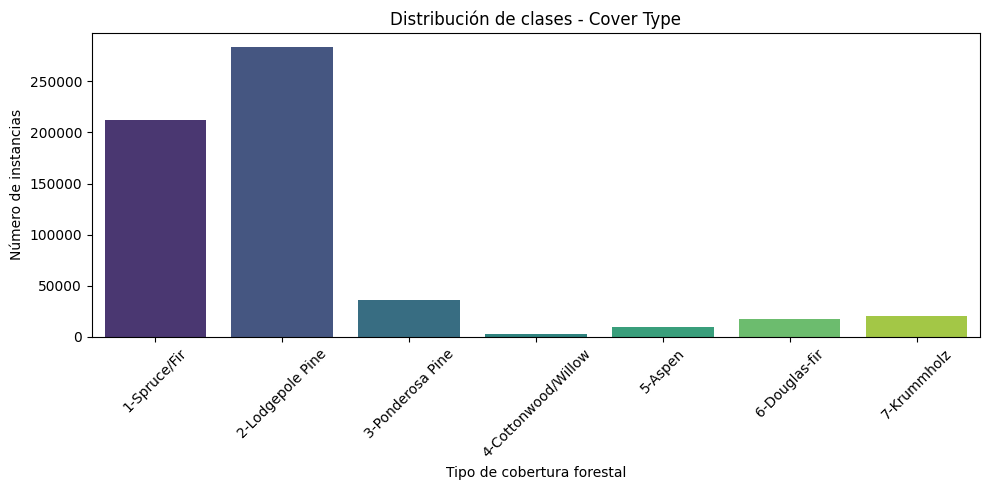

In [6]:
## PON AQUÍ TU CÓDIGO
# Distribución de clases
distribucion = df['Cover_Type'].value_counts().sort_index()
print("Distribución de clases:")
print(distribucion)
print(f"\nPorcentaje por clase:")
print((distribucion / len(df) * 100).round(2))

# Visualización
plt.figure(figsize=(10, 5))
sns.countplot(x='Cover_Type', data=df, palette='viridis')
plt.title('Distribución de clases - Cover Type')
plt.xlabel('Tipo de cobertura forestal')
plt.ylabel('Número de instancias')
plt.xticks(ticks=range(7), labels=[
    '1-Spruce/Fir', '2-Lodgepole Pine', '3-Ponderosa Pine',
    '4-Cottonwood/Willow', '5-Aspen', '6-Douglas-fir', '7-Krummholz'
], rotation=45)
plt.tight_layout()
plt.show()

**Respuesta**

El dataset no está balanceado, ya que existen dos clases dominantes: Spruce/Fir con un 36,46% y Lodgepole Pine con un 48,76%. Solo con estas clases se suma el 85,22% de todas las instancias.

¿Existen valores nulos o perdidos en el dataset?

In [7]:
## PON AQUÍ TU CÓDIGO
print("Valores nulos por columna:")
print(df.isnull().sum())

print(f"\nTotal de valores nulos en el dataset: {df.isnull().sum().sum()}")

Valores nulos por columna:
Elevation                             0
Aspect                                0
Slope                                 0
Horizontal_Distance_To_Hydrology      0
Vertical_Distance_To_Hydrology        0
Horizontal_Distance_To_Roadways       0
Hillshade_9am                         0
Hillshade_Noon                        0
Hillshade_3pm                         0
Horizontal_Distance_To_Fire_Points    0
Wilderness_Area1                      0
Wilderness_Area2                      0
Wilderness_Area3                      0
Wilderness_Area4                      0
Soil_Type1                            0
Soil_Type2                            0
Soil_Type3                            0
Soil_Type4                            0
Soil_Type5                            0
Soil_Type6                            0
Soil_Type7                            0
Soil_Type8                            0
Soil_Type9                            0
Soil_Type10                           0
Soil_Type11  

**Respuesta**

No existen valores nulos ni perdidos, todos los valores de las columnas estan completos.


¿Existe alguna variable altamente correlacionada con la variable de clase?

_Nota: Para responder a esto, como es muy difícil ver la matriz de correlaciones, recomendamos filtrar aquellas correlaciones superiores al 0.80 con la variable de clase.

Variables con correlación > 0.80 con Cover_Type:
Series([], Name: Cover_Type, dtype: float64)


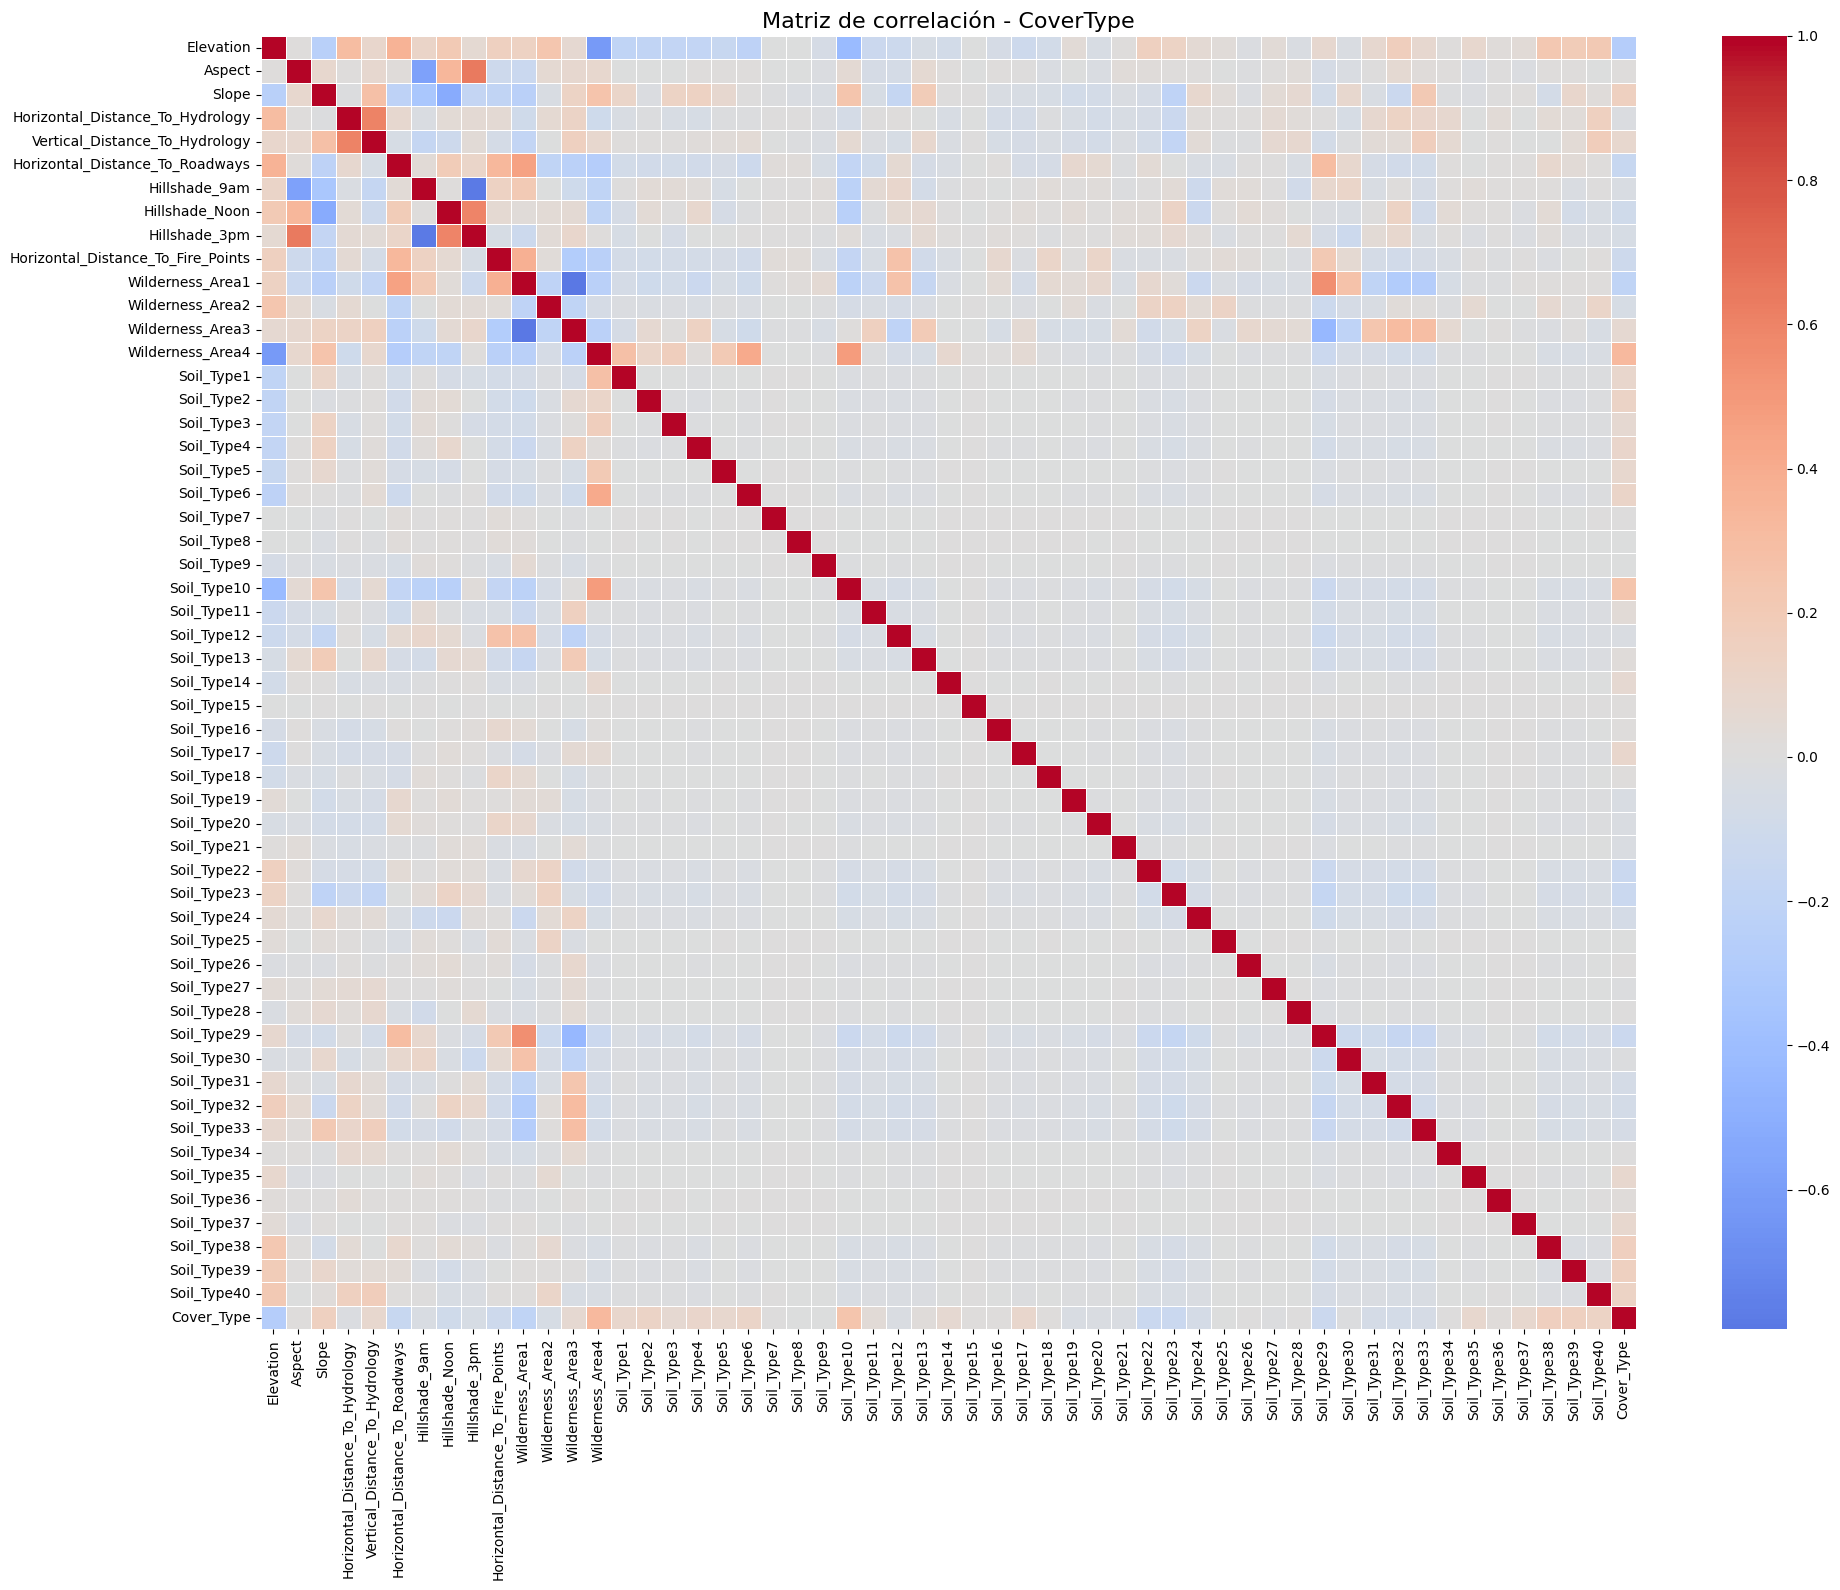

In [8]:
## PON AQUÍ TU CÓDIGO
# Calculamos la correlación de todas las variables con Cover_Type
correlaciones = df.corr()['Cover_Type'].drop('Cover_Type')

# Filtramos las que superan 0.80 en valor absoluto
correlaciones_altas = correlaciones[abs(correlaciones) > 0.80]

print("Variables con correlación > 0.80 con Cover_Type:")
print(correlaciones_altas)

# Visualizamos todas las correlaciones con Cover_Type ordenadas
# Matriz de correlación completa con heatmap
plt.figure(figsize=(20, 16))
sns.heatmap(
    df.corr(),
    annot=False,        # con 55 columnas los números no caben
    cmap='coolwarm',    # azul=correlación negativa, rojo=positiva
    center=0,
    linewidths=0.5
)
plt.title('Matriz de correlación - CoverType', fontsize=16)
plt.tight_layout()
plt.show()

**Resuesta**

Segun la grafica no existe ninguna variable altamente correlacionada con Cover_Type, ninguna supera el 0.80.

¿Qué tres variables del dataset consideras que pueden influenciar más en la clasificación de los datos?¿Qué pruebas harías para comprobar tus hipótesis? **Realiza dichas pruebas**.

/tmp/ipykernel_998/472099672.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cover_Type', y='Elevation', data=df, palette='viridis')


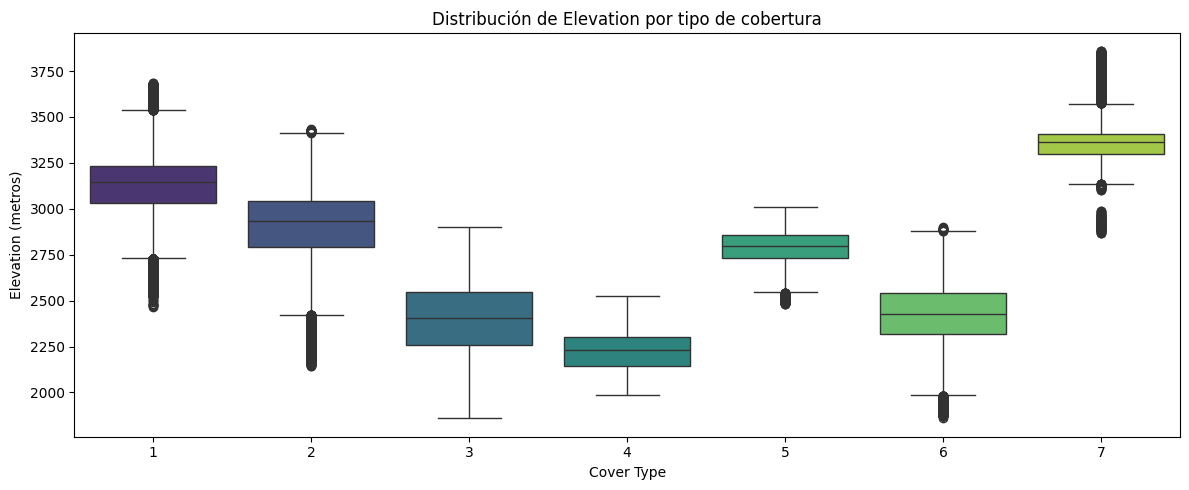

In [9]:
# --- PRUEBA 1: Elevation por clase ---
plt.figure(figsize=(12, 5))
sns.boxplot(x='Cover_Type', y='Elevation', data=df, palette='viridis')
plt.title('Distribución de Elevation por tipo de cobertura')
plt.xlabel('Cover Type')
plt.ylabel('Elevation (metros)')
plt.tight_layout()
plt.show()

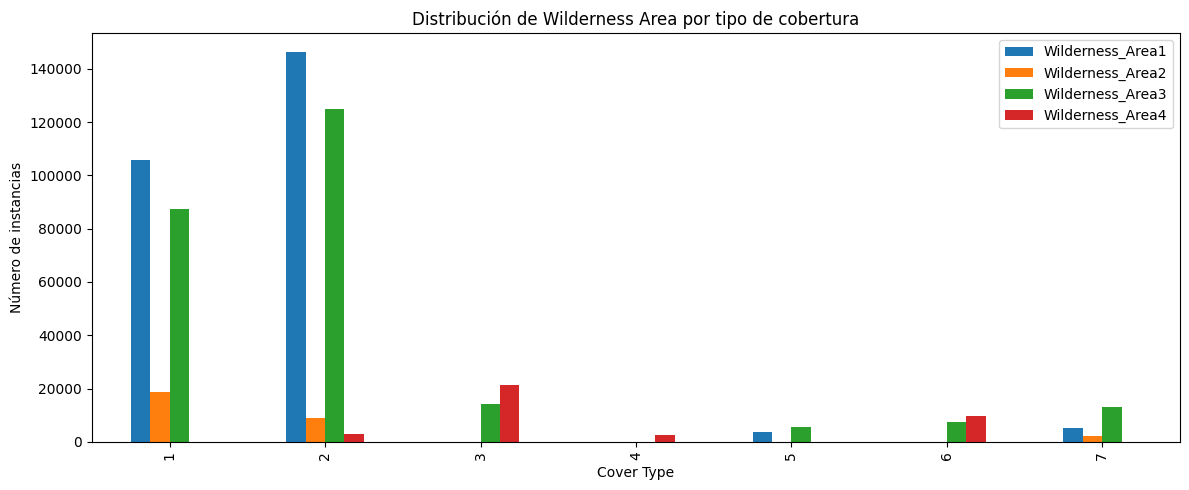

In [10]:
# --- PRUEBA 2: Wilderness Area por clase ---
wilderness_cols = ['Wilderness_Area1','Wilderness_Area2','Wilderness_Area3','Wilderness_Area4']

# Sumamos cuántas instancias de cada clase están en cada área
wilderness_df = df.groupby('Cover_Type')[wilderness_cols].sum()

wilderness_df.plot(kind='bar', figsize=(12, 5))
plt.title('Distribución de Wilderness Area por tipo de cobertura')
plt.xlabel('Cover Type')
plt.ylabel('Número de instancias')
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

/tmp/ipykernel_998/3702864517.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cover_Type', y='Horizontal_Distance_To_Roadways', data=df, palette='viridis')


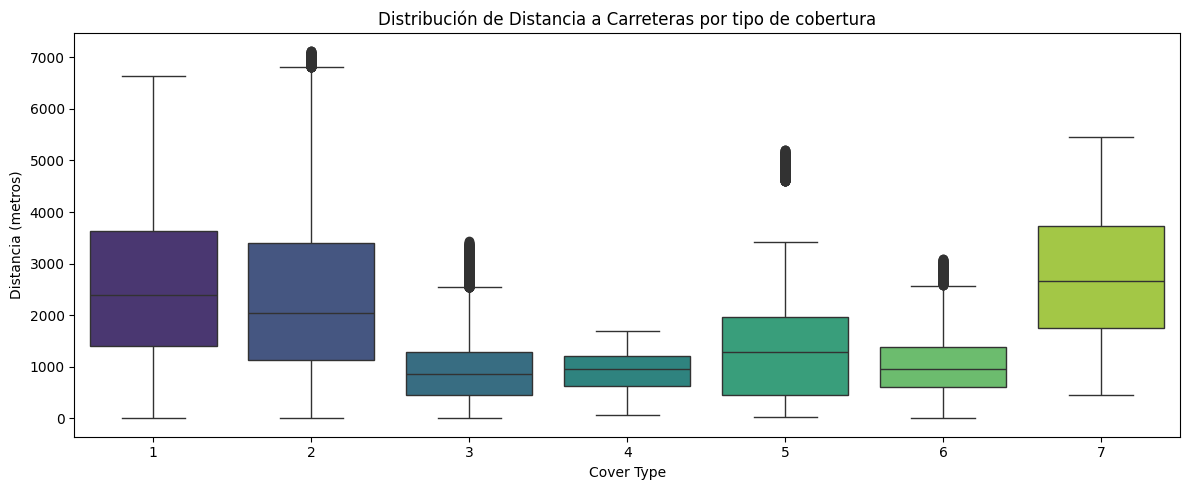

In [11]:
# --- PRUEBA 3: Distancia a carreteras por clase ---
plt.figure(figsize=(12, 5))
sns.boxplot(x='Cover_Type', y='Horizontal_Distance_To_Roadways', data=df, palette='viridis')
plt.title('Distribución de Distancia a Carreteras por tipo de cobertura')
plt.xlabel('Cover Type')
plt.ylabel('Distancia (metros)')
plt.tight_layout()
plt.show()

**RESPUESTA**

Para las pruebas se usaron tres variables bastante influyentes.

Para validar las hipotesis se realizaron boxplots y graficos de barras por cada clase:

* **Elevation** esta variable es la que mejor separa los 7 tipos de bosque, esto seria porque cada tipo crece en altiuras diferentes. En el boxplot las cajas de cada clase esta en pocisiones distintas.

* **Wilderness_Area** segun la grafica separa bien las clases de acuerdo a las areas silvestres. Se puede observar que las clases 1 y 2 se distribuyen mas en las areas 1 y 3, en cambio las clase 3 aparece mas en el area 4.

* **Horizontal_Distance_To_Roadways** si muestra variacion entre las clases pero no es mucha, aun asi se puede observar que las clases 1, 2 y 7 tienden a estar más alejadas de carreteras que las clases 3, 4 y 6.



### Clasificación

In [ ]:
# Separamos los datos en los conjuntos de entrenamiento y test.
from sklearn.model_selection import train_test_split

X, y = df.drop('Cover_Type',axis=1),df['Cover_Type']

X_train,X_test,y_train,y_test = train_test_split(X, y, test_size=0.2, random_state=1)

**Árboles de decisión**

En esta parte de la actividad, hay que utilizar la librería https://scikit-learn.org/stable/modules/tree.html para resolver el problema de clasificación.

El algoritmo Decision Tree necesita ajustar una serie de hiperparámetros para realizar las clasificaciones. La implementación de sklearn nos da mucha flexibilidad para nuestros modelos. En general, para los problemas más comunes de clasificación, nos tenemos que preocupar de los siguientes hiperparámetros:
- max_depth
- min_samples_split
- min_samples_leaf
- max_features
- criterion
- ccp_alpha

**Indica qué son cada uno de estos hiperparámetros**

**RESPUESTA**

- **max_depth:** es la profundidad maxima del arbol, define cuantos niveles de divisiones puede hacer el arbol.
- **min_samples_split:** es el numero minimo de ejemplos o filas del dataset que debe tener un nodo para poder dividirse, si el nodo tiene menos ejemplos que este valor no se divide mas.
- **min_samples_leaf:** se usa para controlar que un nodo resultante de una division tenga suficientes filas o ejemplos.
- **max_features:** es el numero maximo de variables que el arbol evalua antes de cada division. Por ejemplo en este caso si se define el valor de 10, el arbol evaluara solo 10 de las 54 variables antes de dividir un nodo.
- **criterion:** es la formula matematica que usa el arbol para elegir la mejor pregunta para dividir en cada nodo. Ofrece dos opciones las cuales son Gini (mide impureza) y Entropy (mide ganancia de información).
- **ccp_alpha:** es el parametro de poda del arbol, se encarga de recortar las ramas que no aportan mucha informacion o poca precision. Por ejemplo si se definen valores altos se poda más el árbol, reduciendo su complejidad y evitando overfitting.

Además de los hiperparámetros que acabas de descubrir, la implementación de sklearn tiene el hiperparámetro _class_weight_

¿Qué indica ese parámetro? ¿Para qué puede ser útil?

**RESPUESTA**

Este permite asignar mayor peso a las clases minoritarias para el entrenamiento. Es muy útil cuando el dataset está desbalanceado como es este caso, en donde las clases 1 y 2 dominan con el 85% de los datos. Con class_weight='balanced' el modelo le da mas prioridad a las clases con pocas instancias como la clase 4 (Cottonwood/Willow).

Como primer paso para crear un clasificador con Árboles de Decision hay que decidir si hay que hacer algún preprocesamiento adicional sobre los datos.
¿Hace falta normalizar los datos?

**Respuesta**

No hace falta normalizar los datos para Árboles de Decisión porque este algoritmo toma decisiones comparando cada variable consigo misma mediante umbrales (por ejemplo ¿Elevation > 3000?), por lo que la escala de los valores no afecta el resultado. A diferencia de SVM o KNN,  los Árboles de Decisión no les importa si Elevation está en metros (3000) o normalizado (0.85), el resultado es el mismo

In [ ]:
## PON AQUÍ TU RESPUESTA Y/O CÓDIGO


Entrena un conjunto de modelos de árboles de decisión que utilicen todas las variables del dataset, con profundidades máximas de 5, 10, 20, 50 y 100 niveles.

El criterio para realizar las particiones debe ser Gini-index, el número mínimo de ejemplos para realizar una partición debe ser 10, el número mínimo de ejemplos para considerarlo una hoja debe ser 2, y el número máximo de características evaluadas en cada partición deben ser todas.

In [ ]:
max_depth_values =

particion =
min_samples_split =
min_samples_leaf =
max_feature =

decisionTrees = [DecisionTreeClassifier(
        criterion=particion,
        max_depth=i,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        max_features=max_feature
    )    for i in max_depth_values]


In [ ]:
# PON AQUÍ TU CÓDIGO PARA EL ENTRENAMIENTO

Visualiza la matriz de confusión del modelo entrenado con 20 niveles.

In [ ]:
## PON AQUÍ TU CÓDIGO

¿Cuántos ejemplos ha clasificado correctamente?

_PON AQUÍ TU RESPUESTA_

Explica cómo funciona la clasificación **para cada una de las 7 clases**. ¿Hay alguna clase que clasifica mejor que otras?

¿Cuál de todos los modelos que has entrenado obtiene mejores resultados de precisión para el conjunto de datos de test?

_Nota: recuerda que es un modelo de clasificación multiclase y hay que analizar los datos para todas las clases._

In [ ]:
## PON AQUÍ TU CÓDIGO Y RESPUESTA

Selecciona el modelo que consideras que obtiene mejores resultados para los resultados de test. Explica por qué consideras que ese modelo es el que mejor resultados obtiene.

Visualiza la matriz de confusión de los datos de test de este modelo.
- ¿Cuántos ejemplos ha clasificado bien el modelo?
- ¿Cuántos ejemplos ha clasificado de manera errónea?


Visualiza los valores de precision, recall, f1 para cada una de las clases en este modelo ganador.
- ¿Clasifica de igual manera todas las clases o hay alguna para la que el modelo tiene una mayor capacidad predictiva?

In [ ]:
### PON AQUÍ TU CÓDIGO E INDICA TU RESPUESTA

**Support Vector Machine**

In [ ]:
# Importamos las librerías para utilizar las máquinas de vector de soportes.
# Utilizaremos la librería svm:

from sklearn import svm

#Cargamos también las librerías para hacer la matriz de confusión y la cross validation:

from sklearn import metrics
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_val_predict
from sklearn.model_selection import KFold

Para la implementación del modelo de clasificación de SVM usaremos la clase Support Vector Classifier de sklearn, https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html#sklearn.svm.SVC

El algoritmo de SVM necesita ajustar una serie de hiperparámetros para realizar las clasificaciones. La implementación de sklearn nos da mucha flexibilidad para nuestros modelos. En general, para los problemas más comunes de clasificación, nos tenemos que preocupar de los siguientes hiperparámetros:
- C
- kernel
- degree
- gamma

**Indica qué son cada uno de estos hiperparámetros**

_indica aquí tu respuesta_

Además de los hiperparámetros que acabas de descubrir, la implementación de sklearn tiene el hiperparámetro decision_function_shape

¿Qué indica ese parámetro? ¿Para qué puede ser útil?

_indica aquí tu respuesta_

Tenemos un dataset de más de medio millón de instancias, y para el objetivo de la actividad no hacen falta tantas. Por eso, antes de aplicar SVM vamos a reducir el número de instancias. SVM requiere una gran carga computacional y con ese volumen de instancias el tiempo requerido sería demasiado elevado.

In [ ]:
df = df.head(100000)

**Nota: recuerda revisar que esta manera de seleccionar un subconjunto de instancias nos deja un porcentaje similar de instancias de cada clase, esto es, nuestro dataset debe quedar balanceado. Si no fuera así, deberás cambiar la manera de seleccionar el subconjunto.**

In [ ]:
# Comprobamos si efectivamente tenemos un número similar de instancias para cada clase
df['Cover_Type'].value_counts().plot(kind='pie',autopct='%.2f',)
plt.show()

In [ ]:
# Con el nuevo número de instancias, separamos los datos en los conjuntos de entrenamiento y test.
from sklearn.model_selection import train_test_split

X, y = df.drop('Cover_Type',axis=1),df['Cover_Type']

X_train,X_test,y_train,y_test = train_test_split(X, y, test_size=0.2, random_state=1)


Como primer paso para crear un clasificador de SVM hay que decidir si hay que hacer algún preprocesamiento adicional sobre los datos. ¿Hace falta normalizar los datos? Justifica tu respuesta.

In [ ]:
## PON AQUÍ TU CÓDIGO SI CONSIDERAS QUE HAY QUE NORMALIZAR LOS DATOS

from sklearn.preprocessing import StandardScaler
from pandas import DataFrame


scaler = StandardScaler()

## COMPLETAR

Entrena un conjunto de modelos de SVM que utilicen todas las variables del dataset, con C = 0.1 hasta 1000 con cinco valores diferentes. Utiliza kernel radial, y gamma con valor *scale*.

In [ ]:
from sklearn.svm import SVC

C = {}
kernel = ''
gamma = ''

svc = [SVC(C=i, kernel=kernel, gamma=gamma) for i in C]
svc

In [ ]:
### PON AQUÍ TU CÓDIGO

In [ ]:
score

Después de hacer el entrenamiento, visualiza las matrices de confusión de los modelos entrenados.

In [ ]:
## PON AQUÍ TU CÓDIGO

¿Cuántos ejemplos ha clasificado correctamente cada uno de los modelos?

_indica aquí tu respuesta_

Selecciona el modelo que consideras que obtiene mejores resultados y realiza las predicciones con el conjunto de datos de test.

In [ ]:
## PON AQUÍ TU CÓDIGO

Visualiza la matriz de confusión de los datos de test para este modelo ganador.
- ¿Cuántos ejemplos ha clasificado bien el modelo?
- ¿Cuántos ejemplos ha clasificado de manera errónea?

In [ ]:
### PON AQUÍ TU CÓDIGO E INDICA TU RESPUESTA

Visualiza los valores de precision, recall, f1 para cada una de las clases en este modelo ganador.
- ¿Clasifica de igual manera todas las clases o hay alguna para la que el modelo tiene una mayor capacidad predictiva?

In [ ]:
### PON AQUÍ TU CÓDIGO E INDICA TU RESPUESTA

**Comparativa**

En base al EDA realizado, a las decisiones tomadas sobre los datos e hiperparámetros y a las características computacionales de tu equipo. ¿Qué modelo obtiene mejores resultados de clasificación?

### Investigación

Buscar un artículo científico (https://scholar.google.es/) con un caso de uso de **clasificación** empleando una de las dos técnicas (o ambas) vistas en la actividad. Los artículos deben estar en revistas científicas, y deben ser posteriores a 2015. No debe utilizar técnicas de Deep Learning.

_introduce aquí la referencia APA del artículo_

título, autores, revista, año de publicación

Deberás detallar cuál es el **objetivo** de la investigación, es decir a qué problema real está aplicando la clasificación. **Técnicas de clasificación** empleadas y si se realiza alguna adaptación. Principales **resultados** de la aplicación y de la investigación.